In [1]:
import os
from PIL import Image, ImageOps
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_score

2025-04-30 07:37:31.738001: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 07:37:31.739934: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-30 07:37:31.773078: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-30 07:37:31.773910: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-30 07:37:32.387477: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
from deepSVDD import DeepSVDD

In [3]:
from networks import custom_lenet

In [4]:
def augment_image(img):
    augmented_images = []

    # 1. 원본
    augmented_images.append(img.convert('RGB'))  # 알파 채널 제거

    # 2. 좌우 반전
    augmented_images.append(ImageOps.mirror(img.convert('RGB')))  # 알파 채널 제거

    # 3. 상하 반전
    augmented_images.append(ImageOps.flip(img.convert('RGB')))  # 알파 채널 제거

    # 4. 살짝 기울이기
    angle = random.uniform(-10, 10)  # -10도 ~ +10도
    augmented_images.append(img.convert('RGB').rotate(angle, resample=Image.BICUBIC))  # 알파 채널 제거

    # 5. 축소 후 패딩
    shrink_factor = random.uniform(0.8, 0.9)
    w, h = img.size
    new_w, new_h = int(w * shrink_factor), int(h * shrink_factor)
    img_shrink = img.resize((new_w, new_h), resample=Image.Resampling.BICUBIC)
    canvas = Image.new('RGB', (w, h), (0, 0, 0))  # RGB로 캔버스 생성 (알파 채널 제거)
    offset = ((w - new_w) // 2, (h - new_h) // 2)
    canvas.paste(img_shrink, offset)  # 알파 채널 없이 붙이기
    augmented_images.append(canvas)

    return augmented_images

In [5]:
def load_images_from_folder(folder_path, target_size=(128, 128)):
    images = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert('RGB')  # RGBA로 읽기
            img = img.resize(target_size)

            # 증강 적용
            augmented = augment_image(img)
            for aug_img in augmented:
                img_array = np.array(aug_img) / 255.0
                images.append(img_array)

    return np.array(images)

In [6]:
folder_path = '/shared/DeepSVDD/Alpha_images'

In [7]:
images = load_images_from_folder(folder_path)
print('불러온 이미지 개수:', len(images))
print('이미지 shape:', images.shape)

/tmp/ipykernel_50330/3172085769.py:15: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.
  augmented_images.append(img.convert('RGB').rotate(angle, resample=Image.BICUBIC))  # 알파 채널 제거


불러온 이미지 개수: 1175
이미지 shape: (1175, 128, 128, 3)


In [8]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [9]:
def show_augmented_images(images, num_images=10):
    plt.figure(figsize=(15, 5))
    for i in range(min(num_images, len(images))):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.show()

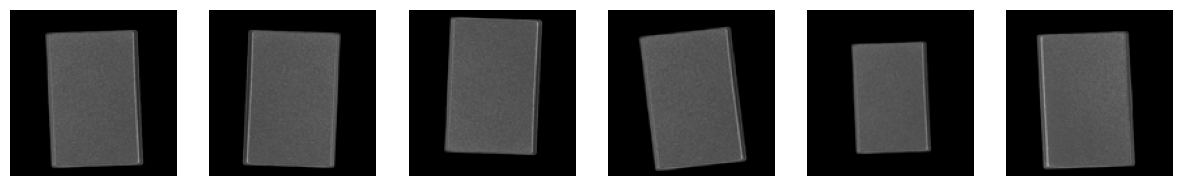

In [10]:
# 시각화
show_augmented_images(images, num_images=6)  

# 학습

In [11]:
input_shape = (128, 128, 3)  # custom_lenet은 64x64x1 입력을 받도록 설계되어 있음
keras_model = custom_lenet(H=128)

2025-04-30 07:37:59.135021: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [12]:
keras_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

In [13]:
model = DeepSVDD(keras_model=keras_model, input_shape=(128, 128, 3), objective='soft-boundary', nu=0.1, representation_dim=128)

In [14]:
images = images.astype(np.float32)  # float32로 변환
model.fit(X_train, epochs=30, batch_size=64, learning_rate=1e-4, nu=0.05)

15/15 [==============================] - 1s 55ms/step


  7%|▋         | 1/15 [00:00<00:05,  2.59it/s]/shared/DeepSVDD/deepSVDD.py:127: RuntimeWarning: invalid value encountered in sqrt
  return np.quantile(np.sqrt(dist), 1 - nu)
100%|██████████| 15/15 [00:03<00:00,  3.98it/s]


Epoch:   0 loss: nan


100%|██████████| 15/15 [00:03<00:00,  4.15it/s]


Epoch:   1 loss: nan


...

Epoch:  27 loss: nan


100%|██████████| 15/15 [00:03<00:00,  4.27it/s]


Epoch:  28 loss: nan


100%|██████████| 15/15 [00:03<00:00,  4.06it/s]

Epoch:  29 loss: nan


# 테스트

In [15]:
def load_test_images_from_folder(folder_path, target_size=(128, 128)):
    images = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert('RGB')  # RGB로 읽기 (알파 채널 제외)
            img = img.resize(target_size)

            img_array = np.array(img) / 255.0  # 정규화
            images.append(img_array)

    return np.array(images)

In [16]:
test_folder_path = '/shared/cropped_dataset/abnormal'

In [17]:
test_images = load_test_images_from_folder(test_folder_path)

In [18]:
# 정상 이미지
X_test_normal = X_test  # 정상 이미지가 담긴 폴더
y_test_normal = np.zeros(len(X_test_normal))  # 정상 데이터는 0 (정상)

# 비정상 이미지
X_test_abnormal = test_images  # 비정상 이미지가 담긴 폴더
y_test_abnormal = np.ones(len(X_test_abnormal))  # 비정상 데이터는 1 (비정상)

# X_test를 두 가지 데이터셋을 합친 형태로 만들기
X_test = np.concatenate([X_test_normal, X_test_abnormal], axis=0)
y_test = np.concatenate([y_test_normal, y_test_abnormal], axis=0)

print(f'정상 이미지 개수: {len(X_test_normal)}')
print(f'비정상 이미지 개수: {len(X_test_abnormal)}')
print(f'전체 테스트 데이터 개수: {len(X_test)}')

정상 이미지 개수: 235
비정상 이미지 개수: 609
전체 테스트 데이터 개수: 844


In [21]:
# 모델 예측
predictions = model.predict(X_test)

14/14 [==============================] - 1s 51ms/step


In [22]:
# 초기 값 설정
best_f1_score = -1  # 최적의 F1 score를 추적하기 위한 초기값
best_threshold = 0  # 최적의 threshold 값
best_accuracy = 0   # 최적의 정확도
best_precision = 0  # 최적의 정밀도
best_recall = 0     # 최적의 재현율

In [23]:
thresholds = list(np.linspace(0.0001, 1.0, 10000))

In [24]:
# threshold별 성능 평가
for threshold in thresholds:
    # 예측값을 threshold에 맞게 0 또는 1로 변환
    binary_predictions = (predictions >= threshold).astype(int)

    # 정확도, 정밀도, 재현율, F1 Score 계산
    accuracy = accuracy_score(y_test, binary_predictions)
    precision = precision_score(y_test, binary_predictions, zero_division=1)  # zero_division 추가
    recall = recall_score(y_test, binary_predictions)
    f1 = f1_score(y_test, binary_predictions)

    # 최적의 Accuracy가 나오는 threshold 저장
    if accuracy > best_accuracy:
        best_f1_score = f1
        best_threshold = threshold
        best_accuracy = accuracy
        best_precision = precision
        best_recall = recall

In [25]:
# 최적의 threshold와 성능 출력
print(f"Best Threshold: {best_threshold}")
print(f"Best F1 Score: {best_f1_score}")
print(f"Best Accuracy: {best_accuracy}")
print(f"Best Precision: {best_precision}")
print(f"Best Recall: {best_recall}")

Best Threshold: 0.1783
Best F1 Score: 1.0
Best Accuracy: 1.0
Best Precision: 1.0
Best Recall: 1.0


In [27]:
# 예측
predictions = model.predict(X_test_abnormal)

10/10 [==============================] - 1s 54ms/step


In [28]:
for i, prediction in enumerate(predictions):
    print(f"Image {i+1}: Predicted Class - {'Abnormal' if prediction >= best_threshold else 'Normal'}")

Image 1: Predicted Class - Abnormal
Image 2: Predicted Class - Abnormal
Image 3: Predicted Class - Abnormal
Image 4: Predicted Class - Abnormal
Image 5: Predicted Class - Abnormal
Image 6: Predicted Class - Abnormal
Image 7: Predicted Class - Abnormal
Image 8: Predicted Class - Abnormal
Image 9: Predicted Class - Abnormal
Image 10: Predicted Class - Abnormal
Image 11: Predicted Class - Abnormal
Image 12: Predicted Class - Abnormal
Image 13: Predicted Class - Abnormal
Image 14: Predicted Class - Abnormal
Image 15: Predicted Class - Abnormal
Image 16: Predicted Class - Abnormal
Image 17: Predicted Class - Abnormal
Image 18: Predicted Class - Abnormal
Image 19: Predicted Class - Abnormal
Image 20: Predicted Class - Abnormal
Image 21: Predicted Class - Abnormal
Image 22: Predicted Class - Abnormal
Image 23: Predicted Class - Abnormal
Image 24: Predicted Class - Abnormal
Image 25: Predicted Class - Abnormal
Image 26: Predicted Class - Abnormal
Image 27: Predicted Class - Abnormal
Image 28: 

In [29]:
# 예측
predictions = model.predict(X_test_normal)

4/4 [==============================] - 0s 53ms/step


In [30]:
for i, prediction in enumerate(predictions):
    print(f"Image {i+1}: Predicted Class - {'Abnormal' if prediction >= best_threshold else 'Normal'}")

Image 1: Predicted Class - Normal
Image 2: Predicted Class - Normal
Image 3: Predicted Class - Normal
Image 4: Predicted Class - Normal
Image 5: Predicted Class - Normal
Image 6: Predicted Class - Normal
Image 7: Predicted Class - Normal
Image 8: Predicted Class - Normal
Image 9: Predicted Class - Normal
Image 10: Predicted Class - Normal
Image 11: Predicted Class - Normal
Image 12: Predicted Class - Normal
Image 13: Predicted Class - Normal
Image 14: Predicted Class - Normal
Image 15: Predicted Class - Normal
Image 16: Predicted Class - Normal
Image 17: Predicted Class - Normal
Image 18: Predicted Class - Normal
Image 19: Predicted Class - Normal
Image 20: Predicted Class - Normal
Image 21: Predicted Class - Normal
Image 22: Predicted Class - Normal
Image 23: Predicted Class - Normal
Image 24: Predicted Class - Normal
Image 25: Predicted Class - Normal
Image 26: Predicted Class - Normal
Image 27: Predicted Class - Normal
Image 28: Predicted Class - Normal
Image 29: Predicted Class - N